Introduction to the Dataset:

Download the dataset from Kaggle.
Load the dataset using Pandas.
Perform initial exploration to understand the dataset structure : whats the distribution of the data? What types of data do i have?
Data Cleaning:

Identify and handle missing values.
Detect and correct any inconsistencies in the data.
Drop irrelevant columns if necessary.




In [4]:
import pandas as pd
mental_health = pd.read_csv(r'C:\Users\njedr\Downloads\Mental Health in Tech Survey\Mental Health in Tech Survey\survey.csv')
df= mental_health.copy()
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [6]:
df.dtypes

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object

In [7]:
df.shape

(1259, 27)

In [8]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [9]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [10]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [11]:
work_miss=df[df['work_interfere'].isnull()]
print(work_miss)
print(f'percentage of missing work_interfere values: {len(work_miss)/len(df)*100:.2f}%')

                Timestamp  Age  Gender         Country state self_employed  \
19    2014-08-27 11:35:08   36    Male          France   NaN           Yes   
26    2014-08-27 11:37:23   33    male   United States    TN            No   
37    2014-08-27 11:41:50   38    Male        Portugal   NaN            No   
38    2014-08-27 11:42:08   50       M   United States    IN            No   
41    2014-08-27 11:42:31   35    Male   United States    MI            No   
...                   ...  ...     ...             ...   ...           ...   
1226  2015-02-21 17:19:18   39    Male     Netherlands   NaN            No   
1229  2015-02-22 02:40:32   39    Male          Greece   NaN            No   
1244  2015-05-05 15:16:25   32  female  United Kingdom   NaN            No   
1254  2015-09-12 11:17:21   26    male  United Kingdom   NaN            No   
1257  2015-11-30 21:25:06   46       f   United States    NC            No   

     family_history treatment work_interfere    no_employees  .

In [12]:
df['work_interfere'].unique

<bound method Series.unique of 0           Often
1          Rarely
2          Rarely
3           Often
4           Never
          ...    
1254          NaN
1255        Often
1256    Sometimes
1257          NaN
1258    Sometimes
Name: work_interfere, Length: 1259, dtype: object>

<Axes: xlabel='work_interfere'>

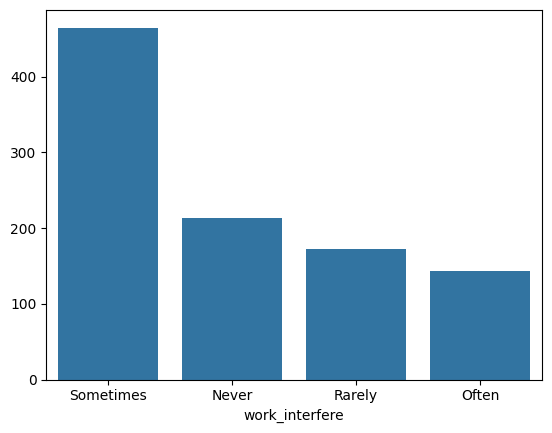

In [13]:
import seaborn as sns
counts = df['work_interfere'].value_counts()
sns.barplot(x=counts.index, y=counts.values)

<Axes: xlabel='work_interfere', ylabel='count'>

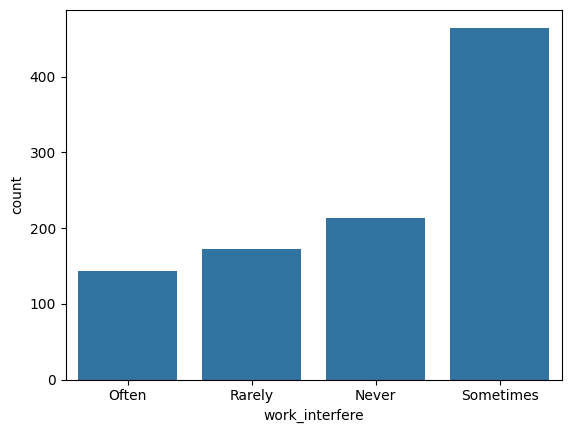

In [14]:
sns.countplot(x='work_interfere', data=df)

since the work_interfere column is important to the dataset and the 'missing values' is significant, its fill with unknown

In [18]:
df['work_interfere']=df['work_interfere'].fillna('Unknown')

In [19]:
df['work_interfere'].value_counts()

work_interfere
Sometimes    465
Unknown      264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

In [ ]:
self_employ_miss=df[df['self_employed'].isnull()] 
print(self_employ_miss.head())
print(f'percentage of missing self_employed values: {len(self_employ_miss)/len(df)*100:.2f}%')

             Timestamp  Age  Gender         Country state self_employed  \
0  2014-08-27 11:29:31   37  Female   United States    IL           NaN   
1  2014-08-27 11:29:37   44       M   United States    IN           NaN   
2  2014-08-27 11:29:44   32    Male          Canada   NaN           NaN   
3  2014-08-27 11:29:46   31    Male  United Kingdom   NaN           NaN   
4  2014-08-27 11:30:22   31    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat easy                        No                      No   
1 

<Axes: xlabel='self_employed', ylabel='count'>

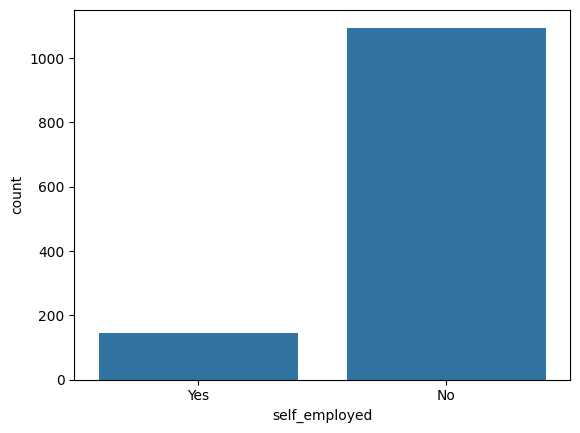

In [20]:
sns.countplot(x='self_employed', data=df)

In [ ]:
state_miss=df[df['state'].isnull()]
print(state_miss)
print(f'percentage of missing state values: {len(state_miss)/len(df)*100:.2f}%')    

                Timestamp  Age  Gender         Country state self_employed  \
2     2014-08-27 11:29:44   32    Male          Canada   NaN           NaN   
3     2014-08-27 11:29:46   31    Male  United Kingdom   NaN           NaN   
7     2014-08-27 11:32:05   39       M          Canada   NaN           NaN   
9     2014-08-27 11:32:43   23    Male          Canada   NaN           NaN   
11    2014-08-27 11:32:49   29    male        Bulgaria   NaN           NaN   
...                   ...  ...     ...             ...   ...           ...   
1244  2015-05-05 15:16:25   32  female  United Kingdom   NaN            No   
1245  2015-05-06 10:14:50   22    Male       Australia   NaN            No   
1247  2015-05-07 10:08:50   36    male         Finland   NaN            No   
1251  2015-08-17 09:38:35   36    Male    South Africa   NaN            No   
1254  2015-09-12 11:17:21   26    male  United Kingdom   NaN            No   

     family_history treatment work_interfere    no_employees  .

In [ ]:
df= df.drop('state', axis =1)

In [ ]:
comment_miss= df[df['comments'].isnull()]
print(comment_miss.head())
print(f'percentage of missing comment values: {len(comment_miss)/len(df)*100:.2f}%')

             Timestamp  Age  Gender         Country self_employed  \
0  2014-08-27 11:29:31   37  Female   United States           NaN   
1  2014-08-27 11:29:37   44       M   United States           NaN   
2  2014-08-27 11:29:44   32    Male          Canada           NaN   
3  2014-08-27 11:29:46   31    Male  United Kingdom           NaN   
4  2014-08-27 11:30:22   31    Male   United States           NaN   

  family_history treatment work_interfere    no_employees remote_work  ...  \
0             No       Yes          Often            6-25          No  ...   
1             No        No         Rarely  More than 1000          No  ...   
2             No        No         Rarely            6-25          No  ...   
3            Yes       Yes          Often          26-100          No  ...   
4             No        No          Never         100-500         Yes  ...   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat easy                    

In [ ]:
df=df.drop('comments', axis=1)

In [ ]:
df.shape

(1259, 25)

In [ ]:
df.head()

,Timestamp,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,2014-08-27 11:29:31,37,Female,United States,NaN,No,Yes,Often,6-25,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,2014-08-27 11:29:37,44,M,United States,NaN,No,No,Rarely,More than 1000,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,2014-08-27 11:29:44,32,Male,Canada,NaN,No,No,Rarely,6-25,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,2014-08-27 11:30:22,31,Male,United States,NaN,No,No,Never,100-500,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [ ]:
df.duplicated().sum()

np.int64(0)